**PSEi: time: 60; {'C': 10, 'epsilon': 0.01, 'gamma': 0.01}**

**PSE: time: 60; {'C': 100, 'epsilon': 0.01, 'gamma': 0.01}**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os

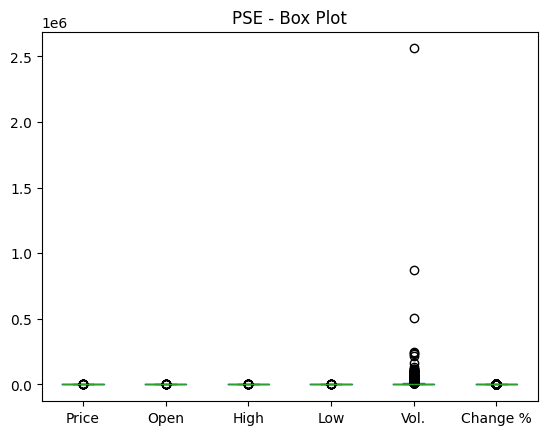

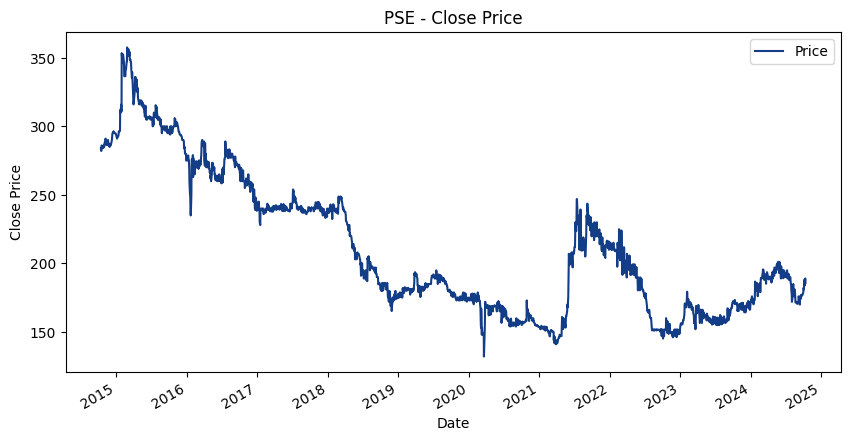

In [ ]:
# Load csv
csv_filename = 'PSE.csv'  # The exact filename being read
data = pd.read_csv(csv_filename)

# Get the filename without extension for the title
filename = os.path.splitext(os.path.basename(csv_filename))[0]

# Convert and sort dates
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

# Function to convert suffixed numbers to numeric values
def convert_volume(volume):
    if isinstance(volume, (int, float)):
        return volume

    if 'K' in volume:
        return float(volume.replace('K', '')) * 1_000
    elif 'M' in volume:
        return float(volume.replace('M', '')) * 1_000_000
    elif 'B' in volume:
        return float(volume.replace('B', '')) * 1_000_000_000
    else:
        try:
            return float(volume)
        except ValueError:
            return np.nan

# Function to convert percentage strings to decimal numbers
def convert_percentage(change):
    if isinstance(change, float):
        return change
    elif isinstance(change, str):
        return float(change.replace('%', '')) / 100
    else:
        return np.nan

# Apply conversions
data['Vol.'] = data['Vol.'].apply(convert_volume)
data['Change %'] = data['Change %'].apply(convert_percentage)

# Original data visualization
data[['Price','Open','High','Low','Vol.', 'Change %']].plot(kind='box')
plt.title(f'{filename} - Box Plot')
plt.show()

# Time series plot of original data
data.plot(x='Date', y='Price', figsize=(10, 5), color='#133E87')
plt.title(f'{filename} - Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [ ]:
# Prepare data for modeling
closing_prices = data.iloc[:, 1:2].values  # Price column
sc = MinMaxScaler(feature_range=(0,1))
scaled_prices = sc.fit_transform(closing_prices)

# Create sequences
timestep = 60
X, y = [], []

for i in range(timestep, len(data)):
    X.append(scaled_prices[i-timestep:i, 0])
    y.append(scaled_prices[i, 0])

X, y = np.array(X), np.array(y)

In [ ]:
# For SVM, we need 2D input instead of 3D
X = X.reshape(X.shape[0], X.shape[1])

# Split the data into train and test sets (80-20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
dates_train = data['Date'].iloc[timestep:train_size+timestep]
dates_test = data['Date'].iloc[train_size+timestep:]

# Build and train the SVM model
model = SVR(kernel='rbf', C=100, epsilon=0.01, gamma=0.01)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform predictions and actual values
predicted_price = sc.inverse_transform(y_pred.reshape(-1, 1))
actual_price = sc.inverse_transform(y_test.reshape(-1, 1))

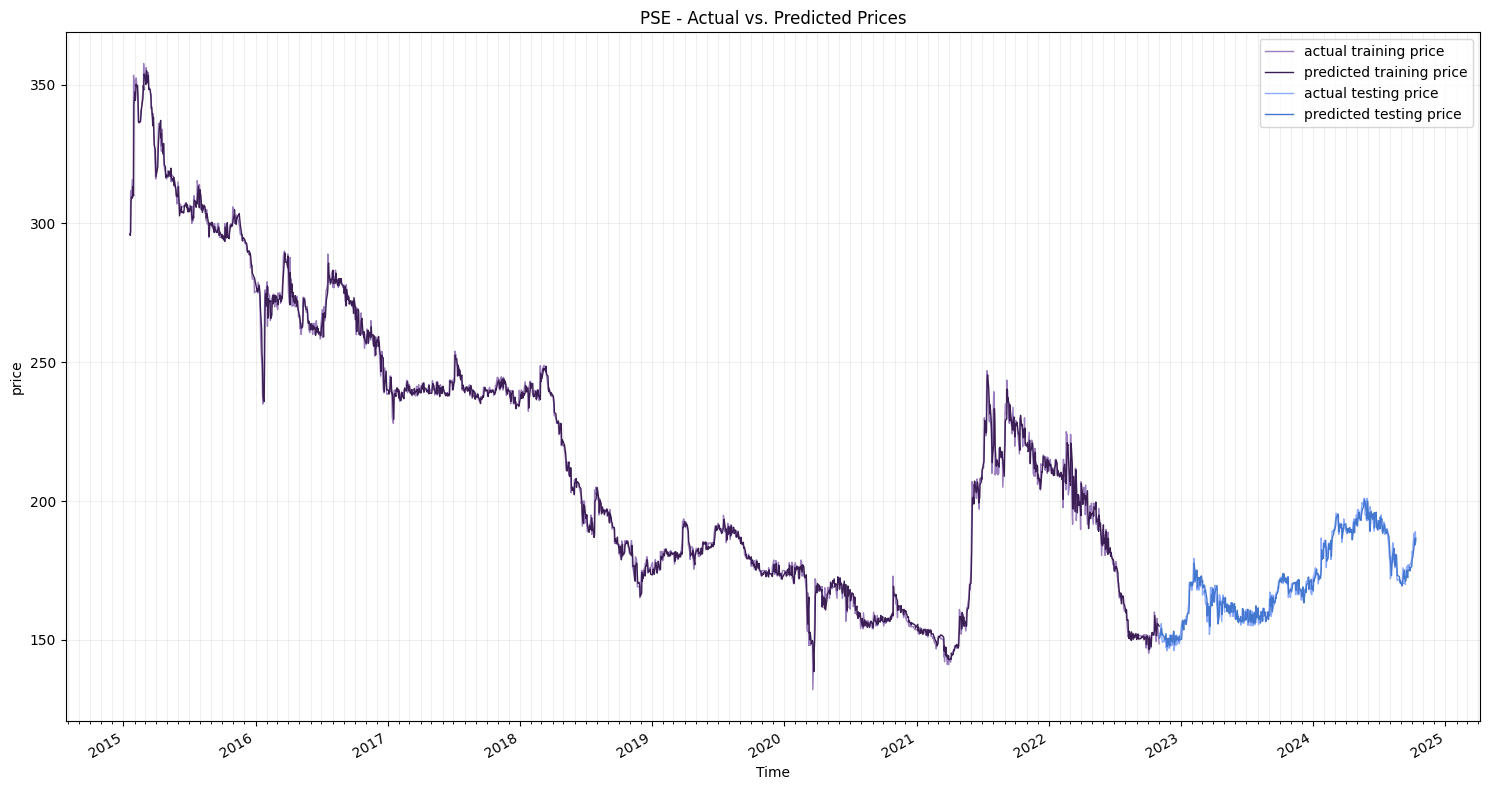


Test Set Performance Metrics:
Mean Squared Error (MSE): 8.36
Mean Absolute Error (MAE): 2.22
Root Mean Squared Error (RMSE): 2.89
R-squared: 0.9575

Training Set Performance Metrics:
Mean Squared Error (MSE): 12.32
Mean Absolute Error (MAE): 2.23
Root Mean Squared Error (RMSE): 3.51
R-squared: 0.9953


In [ ]:
# After making predictions, get training predictions
y_train_pred = model.predict(X_train)

# Inverse transform all predictions and actual values
train_pred = sc.inverse_transform(y_train_pred.reshape(-1, 1))
train_actual = sc.inverse_transform(y_train.reshape(-1, 1))
test_pred = sc.inverse_transform(y_pred.reshape(-1, 1))
test_actual = sc.inverse_transform(y_test.reshape(-1, 1))

# Get dates for plotting
train_dates = dates_train
test_dates = dates_test

# Create the visualization
plt.figure(figsize=(15, 8))
plt.grid(True)

# Plot training data
plt.plot(dates_train, train_actual, '#9B7EBD', label='actual training price', linewidth=1)
plt.plot(dates_train, train_pred, '#3B1E54', label='predicted training price', linewidth=1)

# Plot testing data
plt.plot(dates_test, test_actual, '#8CABFF', label='actual testing price', linewidth=1)
plt.plot(dates_test, test_pred, '#4477CE', label='predicted testing price', linewidth=1)

# Customize the plot
plt.title(f'{filename} - Actual vs. Predicted Prices')
plt.xlabel('Time')
plt.ylabel('price')
plt.legend(loc='upper right')
plt.grid(True, which='both', axis='both', linestyle='-', alpha=0.2)

# Format x-axis to show years
plt.gcf().autofmt_xdate()  # Rotate and align the tick labels
years_fmt = plt.matplotlib.dates.YearLocator()
years_fmt_minor = plt.matplotlib.dates.MonthLocator()
plt.gca().xaxis.set_major_locator(years_fmt)
plt.gca().xaxis.set_minor_locator(years_fmt_minor)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# Evaluate performance
mse = mean_squared_error(test_actual, test_pred)
mae = mean_absolute_error(test_actual, test_pred)
rmse = np.sqrt(mse)
r_squared = r2_score(test_actual, test_pred)

print("\nTest Set Performance Metrics:")
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared: {r_squared:.4f}')

# Calculate training set metrics
train_mse = mean_squared_error(train_actual, train_pred)
train_mae = mean_absolute_error(train_actual, train_pred)
train_rmse = np.sqrt(train_mse)
train_r_squared = r2_score(train_actual, train_pred)

print("\nTraining Set Performance Metrics:")
print(f'Mean Squared Error (MSE): {train_mse:.2f}')
print(f'Mean Absolute Error (MAE): {train_mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {train_rmse:.2f}')
print(f'R-squared: {train_r_squared:.4f}')

In [ ]:
# Future predictions
last_date = data['Date'].iloc[-1]
last_60_days = scaled_prices[- + timestep:].reshape(1, -1)  # Reshape for SVM input

future_predictions = []
future_dates = []

# Predict next 7 working days
num_days_to_predict = 14

for i in range(num_days_to_predict):
    # Make prediction
    next_pred = model.predict(last_60_days)

    # Append prediction and update sequence
    future_predictions.append(next_pred[0])
    last_60_days = np.append(last_60_days[0, 1:], next_pred[0]).reshape(1, -1)

    # Advance the date, skipping weekends
    last_date += pd.Timedelta(days=1)
    while last_date.weekday() >= 5:
        last_date += pd.Timedelta(days=1)
    future_dates.append(last_date)

# Convert predictions back to original scale
future_predictions = sc.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create DataFrame with predictions
future_predictions_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Price': future_predictions.flatten()
})
print("\nFuture Predictions:")
print(future_predictions_df)


Future Predictions:
         Date  Predicted_Price
0  2024-10-14       185.885754
1  2024-10-15       184.930098
2  2024-10-16       183.946224
3  2024-10-17       184.795983
4  2024-10-18       184.135516
5  2024-10-21       183.446288
6  2024-10-22       183.261168
7  2024-10-23       183.358192
8  2024-10-24       183.432431
9  2024-10-25       183.596112
10 2024-10-28       183.427224
11 2024-10-29       183.022839
12 2024-10-30       183.749762
13 2024-10-31       185.037994


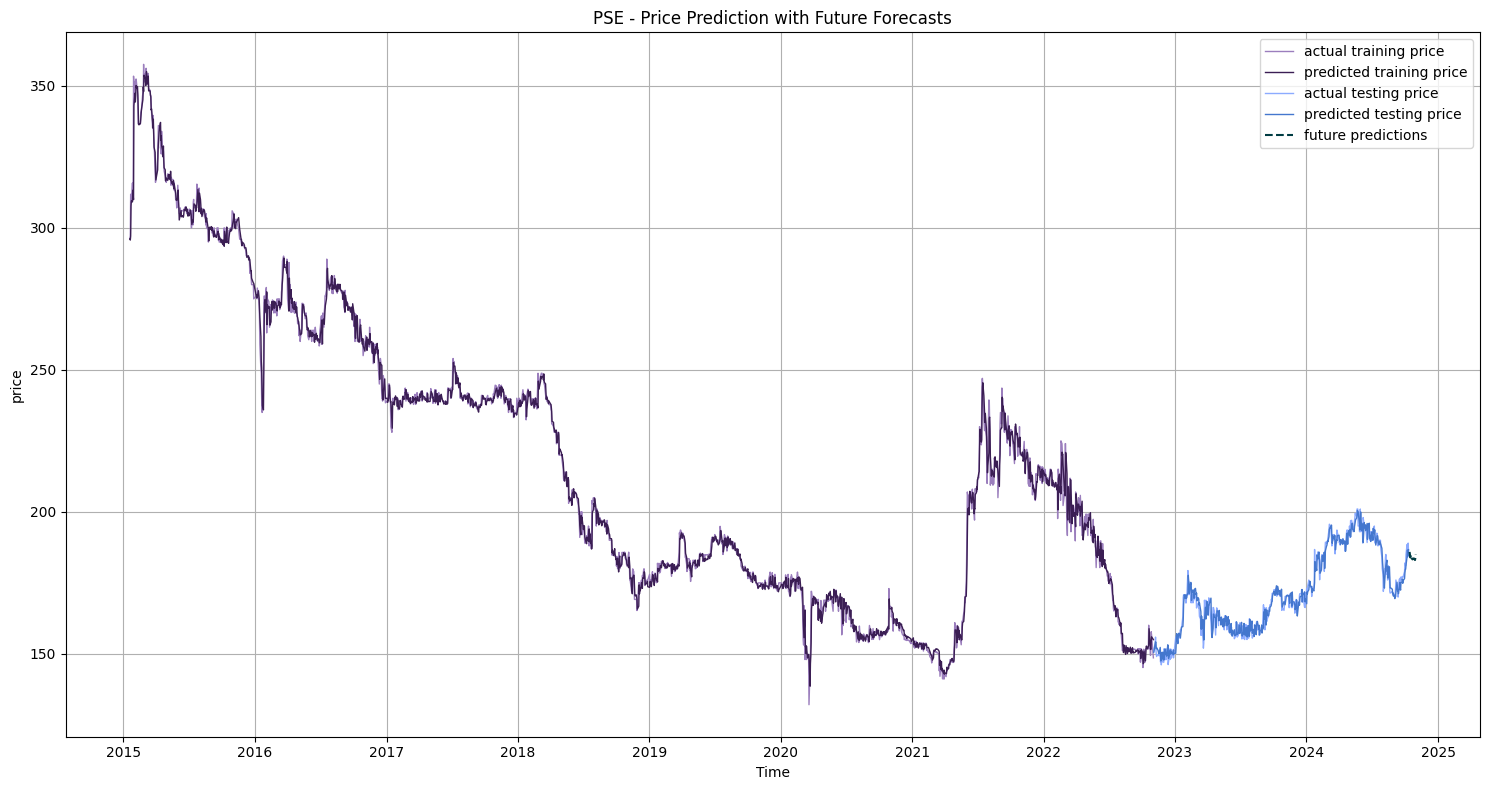

In [ ]:
# Final plot with future predictions
plt.figure(figsize=(15, 8))
plt.grid(True)

# Plot training data
plt.plot(dates_train, train_actual, '#9B7EBD', label='actual training price', linewidth=1)
plt.plot(dates_train, train_pred, '#3B1E54', label='predicted training price', linewidth=1)

# Plot testing data
plt.plot(dates_test, test_actual, '#8CABFF', label='actual testing price', linewidth=1)
plt.plot(dates_test, test_pred, '#4477CE', label='predicted testing price', linewidth=1)

# Plot future predictions
plt.plot(future_predictions_df['Date'], future_predictions_df['Predicted_Price'],
         color='#003C43', linestyle='dashed', label='future predictions')

plt.title(f'{filename} - Price Prediction with Future Forecasts')
plt.xlabel('Time')
plt.ylabel('price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()